In [71]:
%matplotlib widget
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm
from numba import njit
import matplotlib.animation as animation
from matplotlib.widgets import Slider

In [2]:
@njit
def Gibbs_state(L, J, T, sweep): #Gibbs state sampled from the +1 ordered state, to test convergence back to this state
    psi = np.ones((L, L), dtype=np.int64)
    beta = 1/T
    for _ in range(sweep*L*L): #one sweep covers whole site
        i = np.random.randint(0,L)
        j = np.random.randint(0,L)
        # compute neighbor sum with periodic boundary conditions
        neigh = psi[(i+1) % L, j] + psi[(i-1) % L, j] + psi[i, (j+1) % L] + psi[i, (j-1) % L]

        # energy change if flipped
        dE = 2*J*psi[i,j]*neigh

        # Metropolis rule
        if dE <= 0 or np.random.rand() < np.exp(-beta * dE):
                psi[i,j] *= -1
    return psi

In [72]:
@njit
def apply_noise(psi, p):
    flip = np.random.rand(*psi.shape) < p
    return np.where(flip, -psi, psi)

@njit
def s_ij(psi_m, psi_p):
        return psi_m*psi_p

### Zero Temperature Glauber

In [73]:

@njit
def Glauber_sweep(psi): 
        L = psi.shape[0]
        #DE = 0
        for _ in range(L*L):
            i = np.random.randint(0,L)
            j = np.random.randint(0,L)
            
            DE = 0
            
            #calculate syndromes with nns vertically
            DE += s_ij(psi[i,j], psi[(i+1) % L, j])
            DE += s_ij(psi[i,j], psi[(i-1) % L, j])
            DE += s_ij(psi[i,j], psi[i, (j+1) % L])
            DE += s_ij(psi[i,j], psi[i, (j-1) % L])
            
            DE *= 2*J

            if DE < 0:
                psi[i,j] *= -1
            elif DE ==  0:
                if np.random.rand() < 0.5:
                        psi[i,j] *= -1
        return psi


@njit
def Glauber_sweeps(psi, sweeps):
        for _ in range(sweeps):
                psi = Glauber_sweep(psi)
        return psi

### Toom update function

Sequential Tooms

In [360]:
#Sequential version of Tooms in which in a single sweep, overall state is update immediately and next updated site might see the immediate previous update

'''
@njit
def Toom_sweep(psi):
    L = psi.shape[0]
    #new_psi = psi.copy()
    for _ in range(L*L):
            i = np.random.randint(0,L)
            j = np.random.randint(0,L)
            #neighbors:
            north = psi[(i-1) % L, j] #using PBC for now 
            east  = psi[i, (j+1) % L]
            #site
            s = psi[i,j]
            total = s + north + east
            psi[i,j] = 1 if total > 0 else -1 #match sign majority of nearest neighbors
    return psi
@njit
def Toom_sweeps(psi, sweeps):
    for _ in range(sweeps):
        psi = Toom_update(psi)
    return psi
'''

'\n@njit\ndef Toom_sweep(psi):\n    L = psi.shape[0]\n    #new_psi = psi.copy()\n    for _ in range(L*L):\n            i = np.random.randint(0,L)\n            j = np.random.randint(0,L)\n            #neighbors:\n            north = psi[(i-1) % L, j] #using PBC for now \n            east  = psi[i, (j+1) % L]\n            #site\n            s = psi[i,j]\n            total = s + north + east\n            psi[i,j] = 1 if total > 0 else -1 #match sign majority of nearest neighbors\n    return psi\n@njit\ndef Toom_sweeps(psi, sweeps):\n    for _ in range(sweeps):\n        psi = Toom_update(psi)\n    return psi\n'

Asynchronous Tooms

In [74]:
#Synchronous Tooms
@njit
def Toom_sweep(psi):
    L = psi.shape[0]
    new_psi = psi.copy()

    for i in range(L):
        for j in range(L):
            total = psi[i,j] + psi[(i-1) % L, j] + psi[i, (j+1) % L]
            new_psi[i,j] = 1 if total > 0 else -1
    return new_psi

### Dynamical simulations

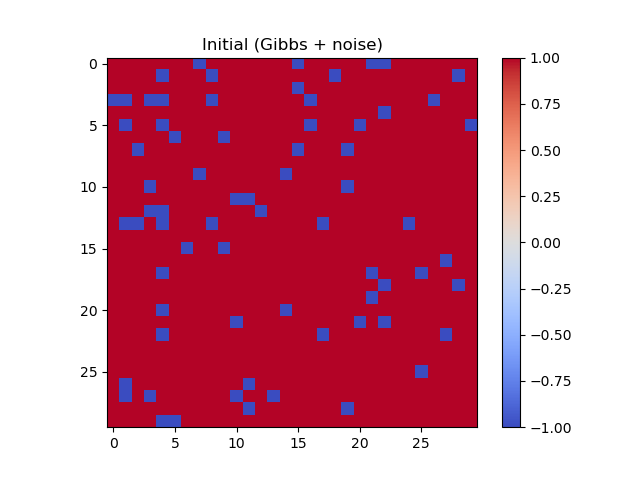

In [132]:
#Now for snapshot simulation
L = 30
J = 1
p_i = 0.08
T_s = 0.000000000000000000000000000001
#psi_init = Gibbs_state(L,J, T_s, sweep=300)
psi_init = np.ones((L, L), dtype=np.int64)
psi_init = apply_noise(psi_init, p_i)

psi_glauber = psi_init.copy()
psi_toom = psi_init.copy()

plt.figure()
plt.imshow(psi_init, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Initial (Gibbs + noise)")
plt.colorbar()
plt.show()

In [133]:
max_steps = 8000

glauber_history = []
toom_history = []
times = []
mg_arr = []
mt_arr = []

glauber_history.append(psi_glauber.copy())
toom_history.append(psi_toom.copy())

for t in tqdm(range(max_steps), desc = "Progression:"):
        psi_glauber = Glauber_sweep(psi_glauber)
        psi_glauber = apply_noise(psi_glauber, p_i)
        m_G = np.sum(psi_glauber)/len(psi_glauber)**2
        mg_arr.append(m_G)
        psi_toom = Toom_sweep(psi_toom)
        psi_toom = apply_noise(psi_toom, p_i)
        m_t = np.sum(psi_toom)/len(psi_toom)**2
        mt_arr.append(m_t)
        
        if t % 1  == 0:
                glauber_history.append(psi_glauber.copy())
                toom_history.append(psi_toom.copy())
                times.append(t)
        '''
        if abs(np.sum(psi)) == L*L: #break loop if convergent to GS
                snapshots.append(psi.copy())
                times.append(t)
                break
        '''
print(len(glauber_history))

Progression:: 100%|██████████| 8000/8000 [00:00<00:00, 9324.27it/s] 

8001


Text(0.5, 0.98, 'Glauber vs Toom (T = 1e-30, p = 0.08)')

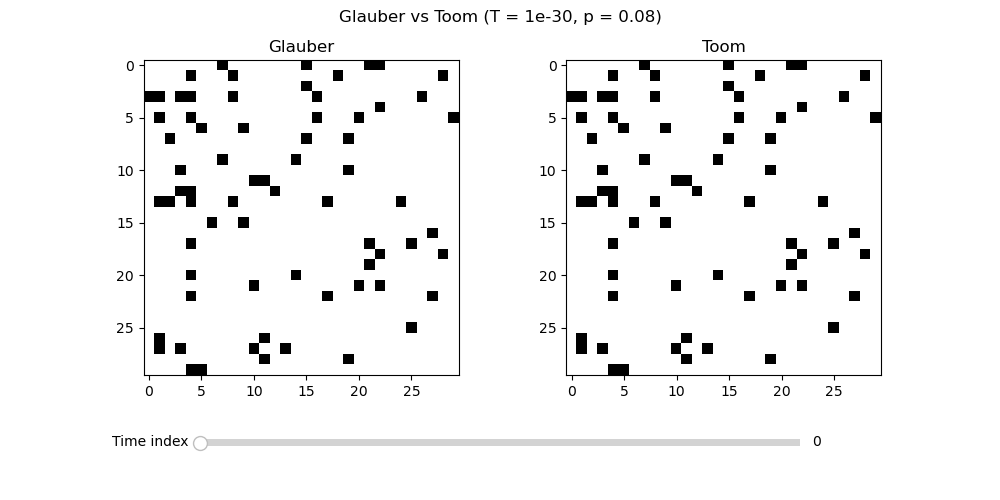

In [134]:
#Plotting, attempting an interactive/dynamic plot
fig, axes = plt.subplots(1, 2, figsize=(10,5))
ax_g, ax_t = axes

plt.subplots_adjust(bottom = 0.25)
cmap = ListedColormap(["black","white"])

im_g = ax_g.imshow(glauber_history[0], cmap=cmap, vmin=-1, vmax=1)
im_t = ax_t.imshow(toom_history[0], cmap=cmap, vmin=-1, vmax=1)

title_g = ax_g.set_title("")
title_t = ax_t.set_title("")

def update_plot(idx):
    snap_g = glauber_history[idx]
    snap_t = toom_history[idx]
    
    im_g.set_data(snap_g)
    im_t.set_data(snap_t)
    
    m_g = np.sum(snap_g) / (L * L)
    m_t = np.sum(snap_t) / (L * L)
    
    title_g.set_text(f"Glauber t={times[idx]}, m={m_g:.2f}")
    title_t.set_text(f"Toom t={times[idx]}, m={m_t:.2f}")
    ax_g.set_title("Glauber")
    ax_t.set_title("Toom")
    
    fig.canvas.draw_idle()

# Slider axis
ax_slider = plt.axes([0.2, 0.1, 0.6, 0.03])
slider = Slider(ax_slider, 'Time index', 0, 200, valinit=0, valstep=1)

def on_slider(val):
    update_plot(int(slider.val))

def save_gif(glauber_history, toom_history, filename="compare.gif", interval=200):
    fig, axes = plt.subplots(1,2)
    cmap = ListedColormap(["black", "white"])

    im_g = axes[0].imshow(glauber_history[0], cmap=cmap, vmin=-1, vmax=1)
    im_t = axes[1].imshow(toom_history[0], cmap=cmap, vmin=-1, vmax=1)
    
    axes[0].axis("off")
    axes[1].axis("off")

    def update(frame):
        im_g.set_array(glauber_history[frame])
        im_t.set_array
        im.set_array(snapshots[frame])
        return [im_g, im_t]

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(glauber_history),
        interval=interval,
        blit=True
    )

    ani.save(filename, writer='pillow')
    plt.close(fig)

    print(f"Saved GIF as {filename}")

slider.on_changed(on_slider)

# initialize display
update_plot(0)

plt.suptitle(f"Glauber vs Toom (T = {T_s}, p = {p_i})")

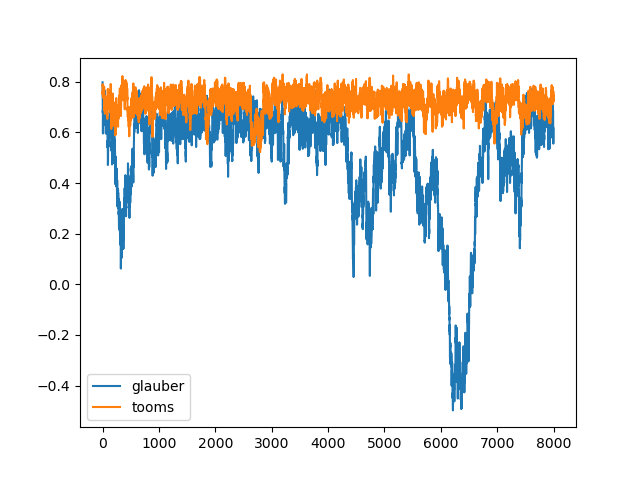

In [135]:
plt.figure()
plt.plot(times, mg_arr, label = "glauber")
plt.plot(times, mt_arr, label = "tooms")
plt.legend()
plt.show()

In [183]:
max_steps = 5000
p_arr = np.linspace(0.045,0.125,60)
mglaub = []
mtooms = []
memtime_g = [] #I define mem time as time for initial failure 
memtime_t = []
t_t = []
t_g = []

for pi in p_arr:
        psi_i = np.ones((L, L), dtype=np.int64)
        psi_g = psi_i.copy()
        psi_t = psi_i.copy()
        t = 0
        t_t.clear()
        t_g.clear()
        for t in tqdm(range(max_steps), desc = "Progression:"):
            psi_g = apply_noise(psi_g, pi)
            psi_g = Glauber_sweep(psi_g)
            psi_t = apply_noise(psi_t, pi)
            psi_t = Toom_sweep(psi_t)
            mt = np.sum(psi_t)/len(psi_t)**2
            mg = np.sum(psi_g)/len(psi_g)**2
            t += 1
            if np.sign(mt) == -1:
                t_t.append(t)
            if np.sign(mg) == -1:
                t_g.append(t)
        if len(t_g) != 0:
            memtime_g.append(min(t_g))
        else:
            memtime_g.append(0)
        if len(t_t) != 0:
            memtime_t.append(min(t_t))
        else:
            memtime_t.append(0)
        mglaub.append(np.sum(psi_g)/len(psi_g)**2)
        mtooms.append(np.sum(psi_t)/len(psi_t)**2)
    
    

Progression:: 100%|██████████| 5000/5000 [00:00<00:00, 10592.56it/s]


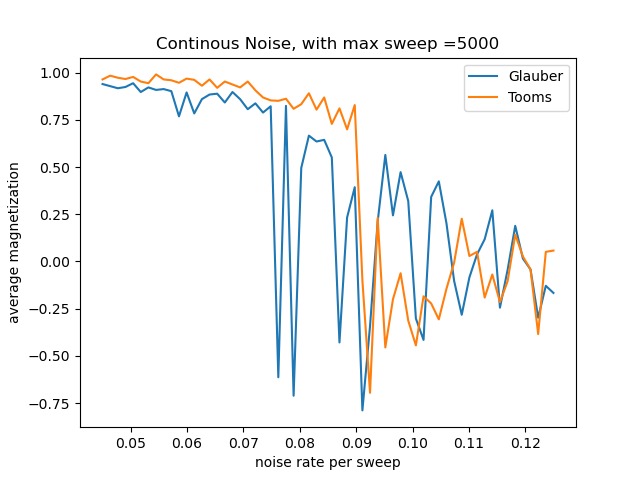

[np.float64(0.9644444444444444), np.float64(0.9844444444444445), np.float64(0.9733333333333334), np.float64(0.9666666666666667), np.float64(0.9777777777777777), np.float64(0.9533333333333334), np.float64(0.9444444444444444), np.float64(0.9911111111111112), np.float64(0.9644444444444444), np.float64(0.96), np.float64(0.9466666666666667), np.float64(0.9688888888888889), np.float64(0.9622222222222222), np.float64(0.9311111111111111), np.float64(0.9644444444444444), np.float64(0.92), np.float64(0.9533333333333334), np.float64(0.9377777777777778), np.float64(0.9222222222222223), np.float64(0.9533333333333334), np.float64(0.9066666666666666), np.float64(0.8688888888888889), np.float64(0.8533333333333334), np.float64(0.8511111111111112), np.float64(0.8622222222222222), np.float64(0.8088888888888889), np.float64(0.8333333333333334), np.float64(0.8911111111111111), np.float64(0.8044444444444444), np.float64(0.8688888888888889), np.float64(0.7288888888888889), np.float64(0.8111111111111111), np.

In [184]:
plt.figure()
plt.title(f"Continous Noise, with max sweep ={max_steps}")
plt.plot(p_arr, mglaub,label = "Glauber")
plt.plot(p_arr, mtooms, label = "Tooms")
plt.xlabel("noise rate per sweep")
plt.ylabel("average magnetization")
plt.legend()
plt.show()
print(mtooms)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2328, 0, 2391, 3946, 0, 4091, 1089, 242, 1594, 415, 225, 502, 1098, 307, 220, 273, 470, 226, 338, 195, 346, 167, 115, 131, 166, 92, 116, 118, 91, 335, 95, 27, 57, 43, 254, 169, 56]


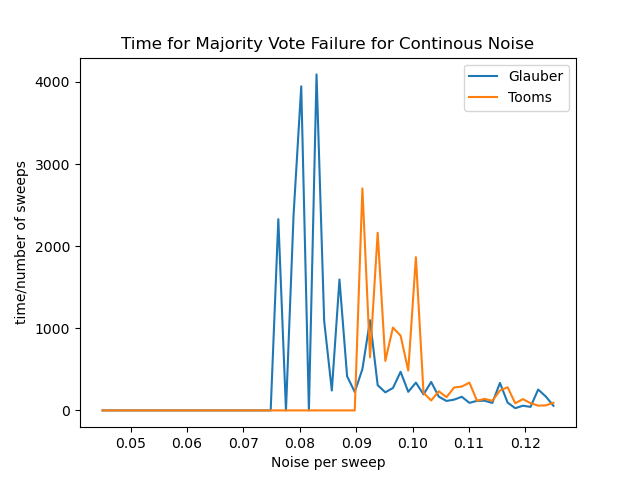

In [187]:
print(memtime_g)
plt.figure()
plt.title("Time for Majority Vote Failure for Continous Noise")
plt.plot(p_arr, memtime_g, label = "Glauber")
plt.plot(p_arr, memtime_t, label = "Tooms")
plt.ylabel("time/number of sweeps")
plt.xlabel("Noise per sweep")
plt.legend()
plt.show()